## Install

Installation is easy just grab it form pip

In [1]:
# !pip install virtughan==0.7.0

## Setup

Define the parameters for your computation

Use this for visual image timeseries
```python
formula="visual"
bands=["visual"]
operation=None
timeseries=True
```

Use this for NDVI on Sentinel-2:
```python
formula="(nir - red) / (nir + red)"
bands=["red", "nir"]
```

The formula references band names directly, and `bands` must list exactly the names the formula uses. Inspect available bands per collection with `get_collection(name).band_names`.

In [2]:
# Define the bounding box
bbox =  [-17.942562103271488,28.569682805210718,-17.839050292968754,28.64689695054486] # cumbre vieja volcano spain area

# Define the parameters
start_date = "2021-10-01"
end_date = "2021-12-30"
cloud_cover = 10
formula = "(nir08 - swir22) / (nir08 + swir22)"  # NBR
bands = ["nir08", "swir22"]
operation = "max"
output_dir = "virtughan_output"
timeseries = True
workers = 6 # no of parallel workers
smart_filter=False

## Cleanup
Lets clear if there are previous output in the dir

In [3]:
import shutil , os
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

## Example compute on time dimension
You can run computation now , You can visualize the results or download them from the files directly after computation is done

In [4]:
from virtughan.engine import VirtughanProcessor

processor = VirtughanProcessor(
    bbox=bbox,
    start_date=start_date,
    end_date=end_date,
    cloud_cover=cloud_cover,
    formula=formula,
    bands=bands,
    operation=operation,
    timeseries=timeseries,
    output_dir=output_dir,
    workers=workers,
    smart_filter=smart_filter,
    cmap="RdYlGn",
)
processor.compute()

Engine starting...

Searching STAC catalog...

Total scenes found: 11

Scenes covering input area: 11

Scenes after removing overlaps: 6

...

PROGRESS: 83% | 5/6

PROGRESS: 100% | 6/6

Aggregating results...

Saving aggregated result with colormap...

Creating GIF and zipping TIFF files...

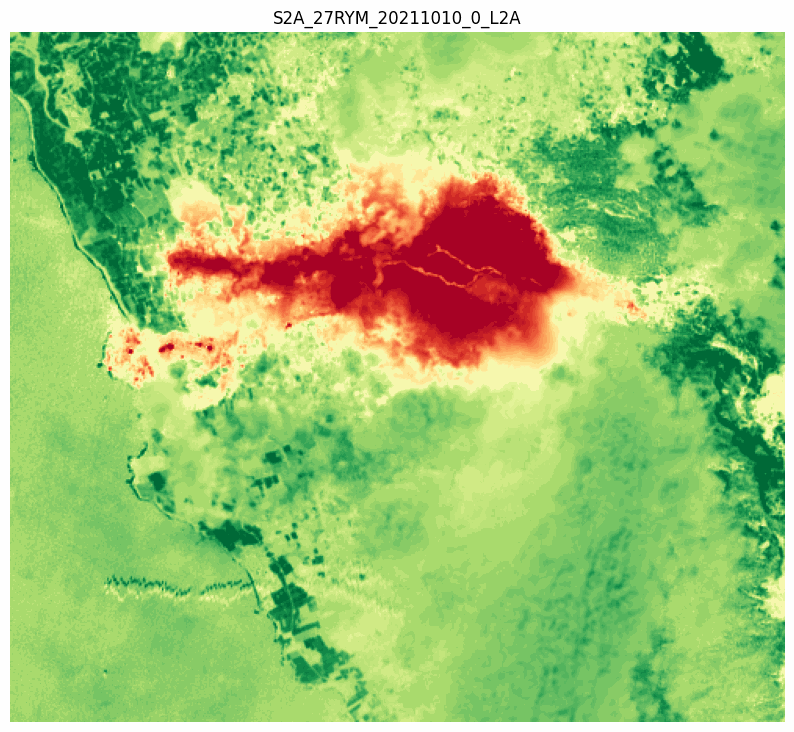

In [5]:
from IPython.display import Image
Image(open(os.path.join(output_dir,'output.gif'),'rb').read())

## Example on the fly tile computation

Here computation will be done alike google earth engine , you zoom out do computation , zoom in do computation based on your formula and resolution will differ accordingly as resampling will happen

In [6]:
import mercantile
from PIL import Image
from io import BytesIO
from virtughan.tile import TileProcessor

# Define the parameters
lat, lon = 28.28139, 83.91866
zoom_level = 12
x, y, z = mercantile.tile(lon, lat, zoom_level)

tile_processor = TileProcessor()

image_bytes, feature = await tile_processor.cached_generate_tile(
    x=x,
    y=y,
    z=z,
    start_date="2020-01-01",
    end_date="2025-01-01",
    cloud_cover=30,
    bands=("red", "nir"),
    formula="(nir - red) / (nir + red)",
    colormap_str="RdYlGn",
)

image = Image.open(BytesIO(image_bytes))

print(f"Tile: {x}_{y}_{z}")
print(f"Date: {feature['properties']['datetime']}")
print(f"Cloud Cover: {feature['properties']['eo:cloud_cover']}%")

image.save(f'tile_{x}_{y}_{z}.png')

Tile: 3002_1712_12
Date: 2024-12-30T05:10:56.883000Z
Cloud Cover: 1.140427%


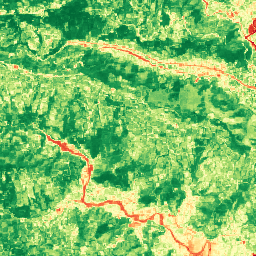

In [7]:
from IPython.display import Image as display_image
display_image(f'tile_{x}_{y}_{z}.png')


## Extract Sentinel-2 Images for your AOI
This example showcase how you can select the band you want and extract sentinel-2 images just for your area of interest

In [8]:
import os

bbox = [83.84765625, 28.22697003891833, 83.935546875, 28.304380682962773]
start_date = "2024-12-15"
end_date = "2024-12-31"
cloud_cover = 30
bands_list = ["blue","green","red", "nir","swir16","swir22"] # order of the bands will result order in the resulting output
output_dir = "./sentinel_images"
workers = 1

os.makedirs(output_dir, exist_ok=True)

In [ ]:
from virtughan.extract import ExtractProcessor
from virtughan.collections import get_collection

config = get_collection("sentinel-2-l2a")
print("Available Sentinel-2 bands:", config.band_names)

extractor = ExtractProcessor(
    bbox,
    start_date,
    end_date,
    cloud_cover,
    bands_list,
    output_dir,
    workers=workers,
)
extractor.extract()

Available Sentinel-2 bands: ['red', 'green', 'blue', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'aot', 'coastal', 'nir09', 'scl', 'visual']


Extracting bands...

Total scenes found: 4

Scenes covering input area: 4

Scenes after removing overlaps: 4

Scenes after smart filter: 4

Output()

## Extract Landsat C2 L2 Images for your AOI
Same workflow as Sentinel-2 but using Landsat collection from Planetary Computer

In [ ]:
from virtughan.collections import get_collection

landsat_config = get_collection("landsat-c2-l2")
print("Available Landsat bands:", landsat_config.band_names)

landsat_bbox = [83.84765625, 28.22697003891833, 83.935546875, 28.304380682962773]
landsat_start_date = "2024-06-01"
landsat_end_date = "2024-08-31"
landsat_cloud_cover = 30
landsat_bands_list = ["blue", "green", "red", "nir08", "swir16", "swir22"]
landsat_output_dir = "./landsat_images"
os.makedirs(landsat_output_dir, exist_ok=True)

Available Landsat bands: ['red', 'green', 'blue', 'nir08', 'swir16', 'swir22', 'coastal', 'lwir11']


In [ ]:
from virtughan.extract import ExtractProcessor

landsat_extractor = ExtractProcessor(
    landsat_bbox,
    landsat_start_date,
    landsat_end_date,
    landsat_cloud_cover,
    landsat_bands_list,
    landsat_output_dir,
    workers=1,
    collection="landsat-c2-l2",
)
landsat_extractor.extract()

Extracting bands...

Total scenes found: 5

Scenes covering input area: 1

Scenes after removing overlaps: 1

Scenes after smart filter: 1

Output()

Stacking bands for LC09_L2SP_142040_20240608_02_T1

PROGRESS: 100% | 1/1

## Landsat NDVI Computation
Compute NDVI using Landsat C2 L2 bands. Note that Landsat uses `nir08` instead of Sentinel-2's `nir`

In [ ]:
landsat_ndvi_output = "./landsat_ndvi_output"
if os.path.exists(landsat_ndvi_output):
    shutil.rmtree(landsat_ndvi_output)

from virtughan.engine import VirtughanProcessor

landsat_processor = VirtughanProcessor(
    bbox=landsat_bbox,
    start_date="2024-06-01",
    end_date="2024-08-31",
    cloud_cover=30,
    formula="(nir08 - red) / (nir08 + red)",
    bands=["red", "nir08"],
    operation="median",
    timeseries=True,
    output_dir=landsat_ndvi_output,
    workers=1,
    collection="landsat-c2-l2",
    cmap="RdYlGn",
)
landsat_processor.compute()

Engine starting...

Searching STAC catalog...

Total scenes found: 5

Scenes covering input area: 1

Scenes after removing overlaps: 1

...

Output()

PROGRESS: 100% | 1/1

Aggregating results...

Saving aggregated result with colormap...

Creating GIF and zipping TIFF files...

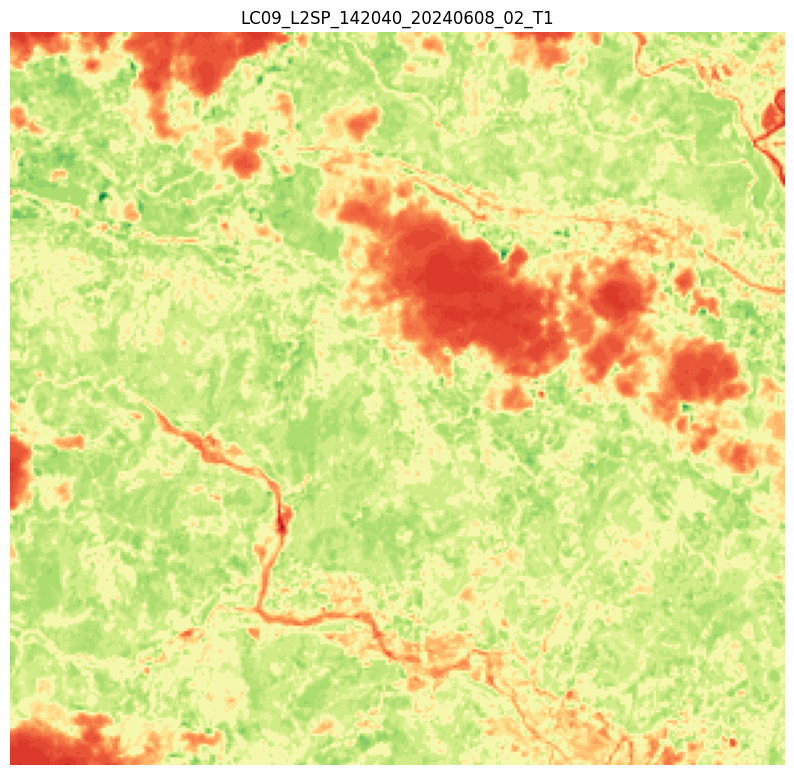

In [ ]:
from IPython.display import Image
Image(open(os.path.join(landsat_ndvi_output, "output.gif"), "rb").read())

## Sentinel-1 SAR: VV/VH cross-pol ratio over Pokhara

This example uses Sentinel-1 RTC (Radiometrically Terrain Corrected) data. Unlike optical bands, S1 has polarization channels (`vv`, `vh`, `hh`, `hv`) and is cloud-penetrating, so `cloud_cover` is ignored. Pixel values are gamma0 in linear scale; we convert to dB inside the formula.

The **VV/VH cross-pol ratio in dB** (`10 * log10(vv / vh)`) is a standard SAR discriminator:
- Dense forest / vegetation: ~3-5 dB (volume scattering depolarizes the signal)
- Sparse vegetation / crops: ~5-8 dB
- Bare or smooth surfaces: ~7-10 dB (surface scattering dominates)

We restrict the search to IW mode (the default S1 mode over land).The Pokhara valley contains Phewa Lake, urban areas, agricultural terraces, and is surrounded by forested hills, so the histogram should span the full range.

In [ ]:
s1_output_dir = "./pokhara_s1_vvvh"
if os.path.exists(s1_output_dir):
    shutil.rmtree(s1_output_dir)

# Phewa Lake / Pokhara valley
pokhara_bbox = [83.92, 28.19, 83.99, 28.24]

s1_processor = VirtughanProcessor(
    bbox=pokhara_bbox,
    start_date="2025-01-01",
    end_date="2025-01-20",
    cloud_cover=0,
    formula="10 * log10(vv / vh)",
    bands=["vv", "vh"],
    operation="median",
    timeseries=True,
    output_dir=s1_output_dir,
    workers=1,
    collection="sentinel-1-rtc",
    cmap="viridis",
    extra_query={"sar:instrument_mode": {"eq": "IW"}},
)
s1_processor.compute()

Engine starting...

Searching STAC catalog...

Total scenes found: 4

Scenes covering input area: 4

Scenes after removing overlaps: 2

...

PROGRESS: 50% | 1/2

PROGRESS: 100% | 2/2

Aggregating results...

Saving aggregated result with colormap...

Creating GIF and zipping TIFF files...

In [ ]:
import rasterio
import numpy as np

with rasterio.open(os.path.join(s1_output_dir, "custom_band_output_aggregate.tif")) as ds:
    data = ds.read(1)
    valid = data[np.isfinite(data)]
    print(f"CRS: {ds.crs}")
    print(f"Shape: {data.shape}")
    print(f"VV/VH ratio (dB) over {valid.size} valid pixels:")
    print(f"  median = {np.median(valid):.2f} dB")
    print(f"  p5     = {np.percentile(valid, 5):.2f} dB  (forest-dominated)")
    print(f"  p95    = {np.percentile(valid, 95):.2f} dB  (bare / smooth)")

CRS: EPSG:32645
Shape: (537, 701)
VV/VH ratio (dB) over 376437 valid pixels:
  median = 6.22 dB
  p5     = 2.43 dB  (forest-dominated)
  p95    = 11.60 dB  (bare / smooth)


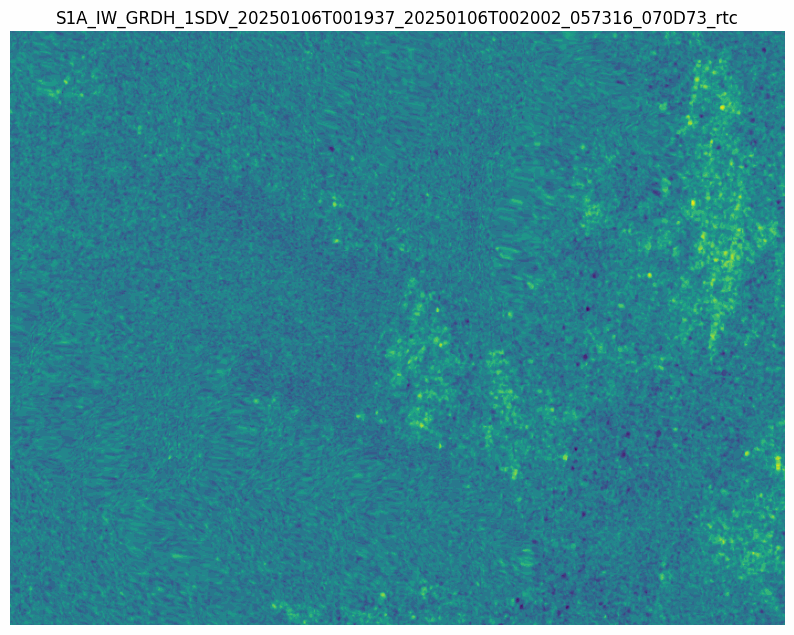

In [ ]:
from IPython.display import Image
Image(open(os.path.join(s1_output_dir, "output.gif"), "rb").read())